In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [129]:
df=pd.read_csv(r"D:\project\data sets\econmic crisis data for train\final data set\global_crisis_new.csv")
target = 'crisis_next_12m'
print('Dataset shape:', df.shape)
print('Target column:', target)
df

Dataset shape: (3864, 14)
Target column: crisis_next_12m


,year,crisis_next_12m,inflation,gdp_growth,unemployment,fed_funds_rate,real_interest_rate_10y,country,iso3,interest_rate,exchange_rate,foreign_reserves,government_debt_gdp,current_account_gdp
0,1960.0,0,NaN,NaN,NaN,3.21,NaN,Maldives,MDV,NaN,4.761900,NaN,NaN,NaN
1,1960.0,0,NaN,NaN,NaN,3.21,NaN,Libya,LBY,NaN,0.357143,8.239000e+07,NaN,NaN
2,1960.0,0,NaN,NaN,NaN,3.21,NaN,Bermuda,BMU,NaN,0.857140,NaN,NaN,NaN
3,1960.0,0,NaN,NaN,NaN,3.21,NaN,Malta,MLT,NaN,0.357143,5.930000e+07,NaN,NaN
4,1960.0,0,0.332829,NaN,NaN,3.21,NaN,Indonesia,IDN,NaN,NaN,3.527392e+08,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3859,2015.0,0,17.149970,2.120759,6.806,0.13,0.589024,Iceland,ISL,7.610000,131.918708,5.040573e+09,116.155545,6.302353
3860,2015.0,0,10.110593,2.920375,11.888,0.13,0.589024,Liechtenstein,LIE,NaN,0.962381,NaN,NaN,NaN
3861,2015.0,0,3.157831,3.840080,6.147,0.13,0.589024,Thailand,THA,4.731875,34.247717,1.564600e+11,36.670570,6.915815
3862,2015.0,0,-0.061645,3.659816,6.813,0.13,0.589024,Uruguay,URY,15.841081,27.327367,1.563385e+10,47.276559,-0.255015


In [130]:
# # ============================================================

# # GLOBAL ECONOMIC CRISIS DATASET

# ============================================================

# فكرة الداتا:

# ------------------------------------------------------------

# الداتا دي عبارة عن Economic Panel Data، يعني بيانات اقتصادية

# لمجموعة كبيرة من الدول عبر سنوات مختلفة.

# الهدف الأساسي من الداتا هو استخدام المؤشرات الاقتصادية

# المختلفة للتنبؤ هل الدولة ستتعرض لأزمة اقتصادية خلال

# الـ 12 شهر القادمة أم لا.

# حجم الداتا:

# ------------------------------------------------------------

# عدد الـ Rows = 3,864

# عدد الـ Columns = 14

# الداتا تحتوي على:

# - 195 دولة تقريبًا

# - السنوات من 1960 إلى 2015

# وبالتالي كل Row بيمثل حالة اقتصادية لدولة معينة في سنة معينة.

# مثال:

# country = Egypt

# year    = 2008

# معناها إن الـ Row ده بيمثل المؤشرات الاقتصادية لمصر

# في سنة 2008.

# ============================================================

# TARGET VARIABLE

# ============================================================

# crisis_next_12m

# دي أهم Column في الداتا لأنها الـ Target Variable.

# وهي Binary Classification Target:

# 0 → لا توجد أزمة اقتصادية خلال الـ 12 شهر القادمة

# 1 → توجد أزمة اقتصادية خلال الـ 12 شهر القادمة

# وبالتالي الـ Machine Learning Model هيحاول يتعلم العلاقة

# بين المؤشرات الاقتصادية الحالية وبين حدوث الأزمة لاحقًا.

# مثال مبسط:

# لو عندنا:

# inflation = مرتفع

# gdp_growth = منخفض

# unemployment = مرتفع

# interest_rate = مرتفع

# الموديل يتعلم من الحالات التاريخية إذا كان هذا النوع من

# الظروف كان مرتبطًا بحدوث أزمة خلال الـ 12 شهر التالية.

# مهم جدًا:

# اسم Target نفسه "crisis_next_12m" معناه إننا لا نتوقع

# الأزمة في نفس السنة بالضرورة، وإنما نحاول التنبؤ بما

# سيحدث خلال الـ 12 شهر التالية.

# ============================================================

# FEATURES

# ============================================================

# 1) year

# ------------------------------------------------------------

# السنة التي تم تسجيل البيانات فيها.

# مثال:

# 2008

# 2009

# 2010

# يمكن استخدامها لمعرفة الاتجاهات الزمنية، ولكن يجب الحذر

# عند استخدامها كـ Feature حتى لا يتعلم الموديل مجرد

# Pattern خاص بالزمن بدلًا من الظروف الاقتصادية الحقيقية.

# 2) inflation

# ------------------------------------------------------------

# معدل التضخم.

# يقيس مدى ارتفاع أسعار السلع والخدمات مع مرور الوقت.

# ارتفاع التضخم بشكل كبير أو غير مستقر قد يكون مؤشرًا

# على وجود مشاكل اقتصادية.

# نوع البيانات:

# Numerical / Continuous

# 3) gdp_growth

# ------------------------------------------------------------

# معدل نمو الناتج المحلي الإجمالي GDP.

# يقيس مدى نمو أو انكماش الاقتصاد.

# قيمة موجبة:

# الاقتصاد ينمو.

# قيمة سالبة:

# الاقتصاد ينكمش.

# الانخفاض الشديد في GDP Growth قد يكون مرتبطًا

# بحدوث أزمات اقتصادية.

# نوع البيانات:

# Numerical / Continuous

# 4) unemployment

# ------------------------------------------------------------

# معدل البطالة.

# يقيس نسبة الأشخاص القادرين على العمل ولكن ليس لديهم عمل.

# ارتفاع البطالة قد يكون علامة على ضعف النشاط الاقتصادي.

# نوع البيانات:

# Numerical / Continuous

# 5) fed_funds_rate

# ------------------------------------------------------------

# Federal Funds Rate.

# وهو معدل فائدة أساسي مرتبط بالسياسة النقدية الأمريكية.

# مهم لأنه يمكن أن يؤثر على:

# - تكلفة الاقتراض

# - الاستثمار

# - التضخم

# - حركة رؤوس الأموال

# - النشاط الاقتصادي العالمي

# وبالتالي يمكن استخدامه كمؤشر للظروف المالية العالمية.

# نوع البيانات:

# Numerical / Continuous

# 6) real_interest_rate_10y

# ------------------------------------------------------------

# معدل الفائدة الحقيقي لمدة 10 سنوات.

# "Real" يعني أنه يأخذ تأثير التضخم في الاعتبار.

# ويمكن استخدامه لفهم تكلفة الاقتراض الحقيقية والظروف

# المالية طويلة الأجل.

# نوع البيانات:

# Numerical / Continuous

# 7) interest_rate

# ------------------------------------------------------------

# معدل الفائدة الخاص بالاقتصاد/الدولة في الـ Row.

# ارتفاع الفائدة يمكن أن يجعل الاقتراض أكثر تكلفة،

# وبالتالي يمكن أن يؤثر على الاستثمار والاستهلاك والنمو.

# نوع البيانات:

# Numerical / Continuous

# 8) exchange_rate

# ------------------------------------------------------------

# سعر صرف العملة.

# يستخدم لتمثيل قيمة العملة المحلية بالنسبة إلى عملة

# مرجعية معينة.

# تغيرات سعر الصرف الكبيرة قد تكون مرتبطة بمشاكل اقتصادية

# أو مالية، خصوصًا في الاقتصادات التي تعتمد بشكل كبير

# على التجارة الخارجية أو التمويل الخارجي.

# نوع البيانات:

# Numerical / Continuous

# 9) foreign_reserves

# ------------------------------------------------------------

# الاحتياطي النقدي الأجنبي للدولة.

# يمثل حجم الأصول/الاحتياطيات الأجنبية التي تمتلكها الدولة.

# ارتفاع الاحتياطيات عادةً يعطي الدولة قدرة أكبر على:

# - دعم العملة

# - تمويل الواردات

# - مواجهة الضغوط الخارجية

# انخفاضها الشديد قد يكون مؤشرًا على وجود ضغط اقتصادي أو

# مالي خارجي.

# نوع البيانات:

# Numerical / Continuous

# 10) government_debt_gdp

# ------------------------------------------------------------

# نسبة الدين الحكومي إلى الناتج المحلي الإجمالي.

# بدلًا من النظر إلى حجم الدين فقط، يتم مقارنته بحجم الاقتصاد.

# مثال:

# government_debt_gdp = 80

# معناها تقريبًا أن الدين الحكومي يعادل 80% من GDP.

# ارتفاع النسبة بشكل كبير قد يعني زيادة العبء المالي

# على الحكومة.

# نوع البيانات:

# Numerical / Continuous

# 11) current_account_gdp

# ------------------------------------------------------------

# رصيد الحساب الجاري كنسبة من GDP.

# Current Account يعكس بشكل عام العلاقة بين الدولة

# والعالم الخارجي من ناحية:

# - التجارة

# - الدخل

# - التحويلات

# وغيرها من التدفقات الخارجية.

# القيمة السالبة تعني وجود Current Account Deficit،

# بينما القيمة الموجبة تعني Current Account Surplus.

# يمكن أن يكون مهمًا في دراسة مدى اعتماد الاقتصاد

# على التمويل الخارجي.

# نوع البيانات:

# Numerical / Continuous

# ============================================================

# COUNTRY IDENTIFICATION

# ============================================================

# 12) country

# ------------------------------------------------------------

# اسم الدولة.

# مثال:

# Egypt

# Korea, Rep.

# Libya

# Maldives

# نوع البيانات:

# Categorical

# 13) iso3

# ------------------------------------------------------------

# كود الدولة المكون من 3 حروف.

# مثال:

# Egypt → EGY

# Korea → KOR

# Libya → LBY

# وهو مجرد Identifier للدولة.

# غالبًا لن تحتاج استخدام country و iso3 الاثنين معًا

# كـ Features.

# ============================================================

# طبيعة المشكلة

# ============================================================

# المشكلة هنا:

# SUPERVISED LEARNING

# وتحديدًا:

# BINARY CLASSIFICATION

# لأن الـ Target عندنا عبارة عن:

# 0 أو 1

# والمطلوب من الموديل:

# Predict P(crisis_next_12m = 1)

# أي تقدير احتمال حدوث أزمة اقتصادية خلال الـ 12 شهر

# التالية بناءً على المؤشرات الاقتصادية المتاحة.

# ============================================================

# ملاحظة مهمة جدًا

# ============================================================

# الداتا فيها Missing Values بشكل كبير في بعض الـ Features.

# تقريبًا:

# government_debt_gdp      → Missing حوالي 90%

# interest_rate            → Missing حوالي 66%

# unemployment             → Missing حوالي 46%

# current_account_gdp      → Missing حوالي 46%

# real_interest_rate_10y   → Missing حوالي 39%

# foreign_reserves         → Missing حوالي 29%

# inflation                → Missing حوالي 15%

# gdp_growth               → Missing حوالي 8%

# لذلك لا يصح أن نبدأ مباشرة بتدريب Model.

# لازم الأول نعمل:

# 1. Data Cleaning

# 2. Missing Values Analysis

# 3. Outlier Analysis

# 4. Distribution Analysis

# 5. Correlation Analysis

# 6. Feature Engineering

# 7. Encoding للـ Categorical Variables إذا احتجنا

# 8. معالجة Imbalanced Target

# 9. Train/Test Split مناسب للـ Time Series / Panel Data

# ============================================================

# أهم نقطة في المشروع

# ============================================================

# لازم ننتبه جدًا لـ Data Leakage.

# لأن الهدف هو:

# استخدام معلومات السنة الحالية

# للتنبؤ بما سيحدث خلال الـ 12 شهر القادمة.

# لذلك لا يجب إدخال أي معلومة لم تكن متاحة وقت التنبؤ

# أو أي Feature تم حسابها باستخدام معلومات مستقبلية.

# كذلك يفضل عدم عمل Random Train/Test Split بشكل عشوائي

# بدون التفكير في البعد الزمني.

# الأفضل التفكير في تقسيم زمني مثل:

# Training → السنوات الأقدم

# Validation → سنوات لاحقة

# Testing → أحدث سنوات

# حتى يكون الاختبار أقرب للواقع:

# "هل أستطيع استخدام البيانات القديمة للتنبؤ بأزمة مستقبلية؟"

# ============================================================

# الهدف النهائي للمشروع

# ============================================================

# الهدف ليس فقط معرفة:

# هل حدثت أزمة أم لا؟

# وإنما يمكن جعل المشروع ينتج:

# Probability of Economic Crisis

# مثال:

# Probability = 0.82

# أي أن الموديل يقدر احتمال حدوث أزمة خلال الـ 12 شهر

# القادمة بحوالي 82%.

# وبالتالي المشروع يصبح أقرب إلى:

# Economic Crisis Early Warning System

# وليس مجرد Classification Model عادي.

# ============================================================

In [131]:
df["year"].unique
#بنعرف رنج السنين الي مغطياها الداتا علشان في داتا بتاعت التوقع يحذف السنين ده علشان الموديل هيكون شافها مرتين

<bound method Series.unique of 0       1960.0
1       1960.0
2       1960.0
3       1960.0
4       1960.0
         ...  
3859    2015.0
3860    2015.0
3861    2015.0
3862    2015.0
3863    2015.0
Name: year, Length: 3864, dtype: float64>

In [132]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3864 entries, 0 to 3863
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   year                    3864 non-null   float64
 1   crisis_next_12m         3864 non-null   int64  
 2   inflation               3287 non-null   float64
 3   gdp_growth              3563 non-null   float64
 4   unemployment            2077 non-null   float64
 5   fed_funds_rate          3864 non-null   float64
 6   real_interest_rate_10y  2346 non-null   float64
 7   country                 3864 non-null   str    
 8   iso3                    3864 non-null   str    
 9   interest_rate           1304 non-null   float64
 10  exchange_rate           3824 non-null   float64
 11  foreign_reserves        2752 non-null   float64
 12  government_debt_gdp     377 non-null    float64
 13  current_account_gdp     2103 non-null   float64
dtypes: float64(11), int64(1), str(2)
memory usage: 471.

In [133]:
df.describe()

,year,crisis_next_12m,inflation,gdp_growth,unemployment,fed_funds_rate,real_interest_rate_10y,interest_rate,exchange_rate,foreign_reserves,government_debt_gdp,current_account_gdp
count,3864.000000,3864.000000,3287.000000,3563.000000,2077.000000,3864.000000,2346.000000,1304.000000,3.824000e+03,2.752000e+03,377.000000,2103.000000
mean,1987.500000,0.243012,26.521509,3.877738,7.361600,5.255536,2.860591,22.041565,1.758363e+06,1.212778e+10,66.636128,-1.718717
std,16.165322,0.428958,280.326539,4.437960,4.623869,3.546271,1.775946,126.307780,1.087195e+08,3.789994e+10,164.175929,18.257671
min,1960.000000,0.000000,-8.422486,-36.391977,0.190000,0.090000,-0.013249,1.000000,8.216549e-13,-4.810496e+06,1.956575,-147.997312
25%,1973.750000,0.000000,2.491026,1.792397,4.154000,3.140000,1.445796,8.733989,1.000000e+00,1.320460e+08,28.131976,-6.385038
50%,1987.500000,0.000000,5.409549,3.967981,6.547000,5.035000,2.800699,12.045358,3.580000e+00,7.924331e+08,45.834694,-2.614663
75%,2001.250000,0.000000,11.616330,6.076601,9.404000,7.270000,4.048303,17.708333,3.813493e+01,5.875179e+09,67.461151,0.857760
max,2015.000000,1.000000,11749.639632,42.410414,31.840000,16.390000,6.934689,4260.014159,6.723052e+09,3.667073e+11,2003.941756,235.750605


In [134]:
# نعرض نوع كل عمود وعدد القيم المفقودة وعدد القيم المختلفة.
# الهدف هو فهم شكل البيانات قبل عمل أي رسم.
overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'unique_values': df.nunique(dropna=False),
    'missing_values': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2)
})
display(overview)


,dtype,unique_values,missing_values,missing_percent
year,float64,56,0,0.00
crisis_next_12m,int64,2,0,0.00
inflation,float64,3288,577,14.93
gdp_growth,float64,3562,301,7.79
unemployment,float64,1660,1787,46.25
fed_funds_rate,float64,54,0,0.00
real_interest_rate_10y,float64,35,1518,39.29
country,str,195,0,0.00
iso3,str,195,0,0.00
interest_rate,float64,842,2560,66.25


In [135]:
df.duplicated().sum()

np.int64(2)

In [136]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [137]:
# Correlation يحتاج إلى أرقام، لذلك نختار الأعمدة الرقمية فقط ونستبعد الـ Target نفسه من قائمة Features.
#ده قبل مسح الاعمده وي ال feature enginering 
numeric_features_before = df.select_dtypes(include='number').columns.tolist()
numeric_features = [col for col in numeric_features_before if col != target]

print('Numeric features used in correlation and plots:')
print(numeric_features)
print(f"numbers of numerical features:{len(numeric_features_before)} from total columns:{df.shape[1]}")




Numeric features used in correlation and plots:
['year', 'inflation', 'gdp_growth', 'unemployment', 'fed_funds_rate', 'real_interest_rate_10y', 'interest_rate', 'exchange_rate', 'foreign_reserves', 'government_debt_gdp', 'current_account_gdp']
numbers of numerical features:12 from total columns:14


In [138]:
# Correlation يحتاج إلى أرقام، لذلك نختار الأعمدة الرقمية فقط ونستبعد الـ Target نفسه من قائمة Features.
str_features = df.select_dtypes(include='str').columns.tolist()
str_features = [col for col in str_features if col != target]

print('str features used in correlation and plots:')
print(str_features)
print(f"numbers of numerical features:{len(str_features)} from total columns:{df.shape[1]}")




str features used in correlation and plots:
['country', 'iso3']
numbers of numerical features:2 from total columns:14


In [139]:
corrleation_before=df.drop(df[str_features].columns, axis=1).corr()
corrleation_before

,year,crisis_next_12m,inflation,gdp_growth,unemployment,fed_funds_rate,real_interest_rate_10y,interest_rate,exchange_rate,foreign_reserves,government_debt_gdp,current_account_gdp
year,1.000000,0.112248,-0.004999,-0.118537,0.161352,-0.415473,-0.955821,-0.050033,0.020481,0.280725,-0.321614,0.051023
crisis_next_12m,0.112248,1.000000,0.120402,-0.175283,0.126112,0.118924,0.235121,0.045362,-0.009122,-0.003234,-0.062539,-0.003970
inflation,-0.004999,0.120402,1.000000,-0.071929,0.051510,0.042832,0.072113,-0.001390,-0.001400,-0.015847,-0.010998,0.054616
gdp_growth,-0.118537,-0.175283,-0.071929,1.000000,-0.198273,0.001332,-0.053505,-0.020222,-0.031947,-0.028342,0.013402,0.015804
unemployment,0.161352,0.126112,0.051510,-0.198273,1.000000,-0.083879,0.034722,-0.025364,-0.002704,-0.002417,-0.081624,-0.032970
fed_funds_rate,-0.415473,0.118924,0.042832,0.001332,-0.083879,1.000000,0.952818,0.057972,-0.015215,-0.200811,0.100309,-0.037617
real_interest_rate_10y,-0.955821,0.235121,0.072113,-0.053505,0.034722,0.952818,1.000000,0.072410,-0.018147,-0.231667,0.042159,-0.044600
interest_rate,-0.050033,0.045362,-0.001390,-0.020222,-0.025364,0.057972,0.072410,1.000000,-0.011514,-0.038014,0.274150,-0.014520
exchange_rate,0.020481,-0.009122,-0.001400,-0.031947,-0.002704,-0.015215,-0.018147,-0.011514,1.000000,-0.006094,-0.008439,-0.030427
foreign_reserves,0.280725,-0.003234,-0.015847,-0.028342,-0.002417,-0.200811,-0.231667,-0.038014,-0.006094,1.000000,-0.044999,0.081742


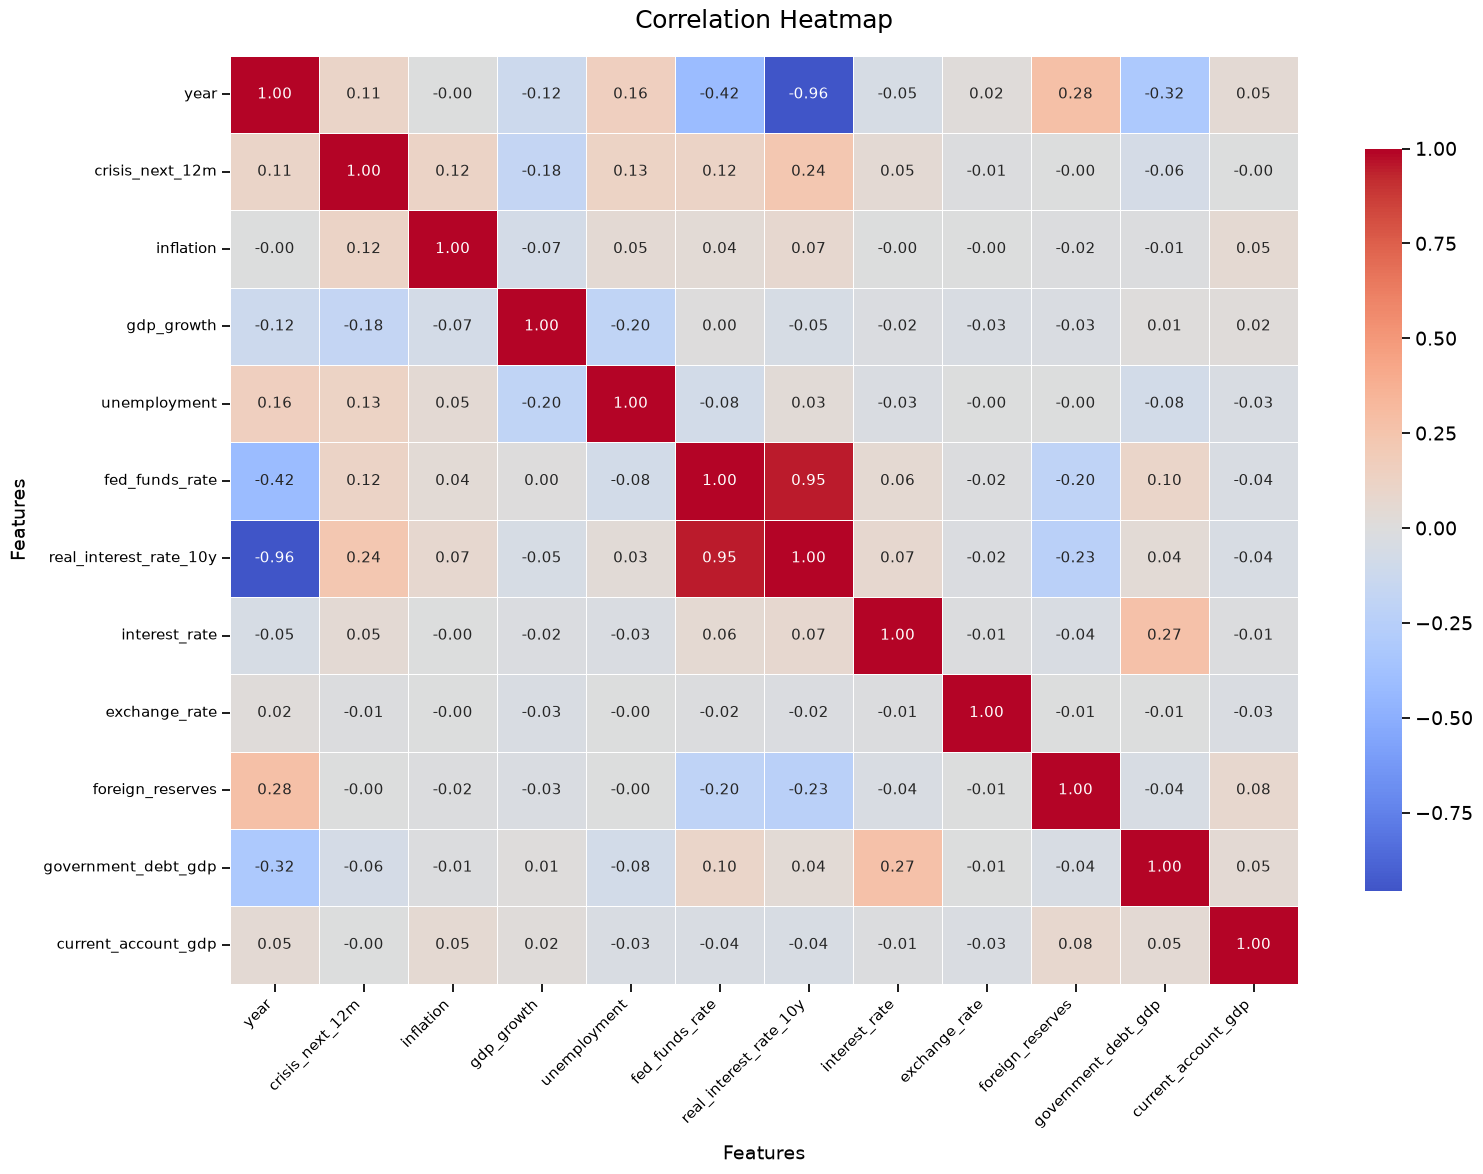

In [140]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    corrleation_before,
    annot=True,              # إظهار أرقام الـ Correlation داخل الخلايا
    fmt='.2f',               # عرض الرقم بمنزلتين عشريتين
    cmap='coolwarm',         # ألوان توضح القيم السالبة والموجبة
    center=0,                # جعل الصفر في منتصف مقياس الألوان
    linewidths=0.5,          # إضافة مسافات بين الخلايا
    linecolor='white',
    annot_kws={'size': 11},  # تكبير حجم الأرقام داخل الخلايا
    cbar_kws={'shrink': 0.8} # ضبط حجم شريط الألوان الجانبي
)

plt.title('Correlation Heatmap', fontsize=18, pad=20)
plt.xlabel('Features', fontsize=14, labelpad=10)
plt.ylabel('Features', fontsize=14, labelpad=10)

# تكبير أسماء الأعمدة والصفوف
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

<Axes: >

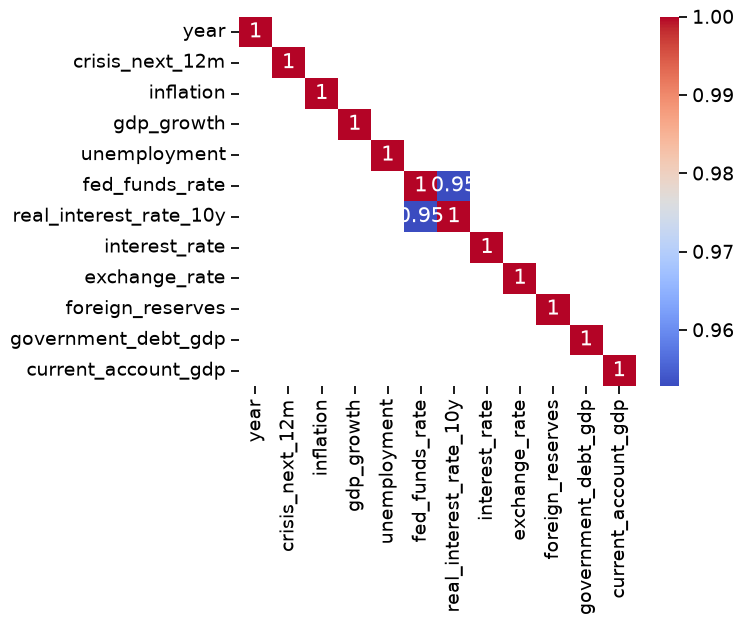

In [141]:
sns.heatmap(corrleation_before, annot=True,mask=corrleation_before<.90, cmap='coolwarm')

In [142]:
# ============================================================
# Feature Engineering
# ============================================================
# لازم نرتب الداتا بالـ iso3 و year الأول عشان نحسب التغيرات الزمنية صح لكل دولة لوحدها
df = df.sort_values(["iso3", "year"]).reset_index(drop=True)

# 1) inflation_change: هل التضخم بيتسارع ولا بيهدى عن السنة اللي فاتت (لنفس الدولة)
df["inflation_change"] = df.groupby("iso3")["inflation"].diff()

# 2) gdp_growth_change: هل معدل نمو الاقتصاد بيتحسن ولا بيتراجع عن السنة اللي فاتت
df["gdp_growth_change"] = df.groupby("iso3")["gdp_growth"].diff()
# ملحوظة: أول سنة لكل دولة هيكون الـ diff بتاعها NaN (مفيش سنة قبلها نقارن بيها)
# ده طبيعي وهيتعالج مع باقي الـ nulls في خطوة الـ median fill
#ضفتهم علشان اعمل عليهم ال ANYLASIS 
df.drop(["government_debt_gdp","real_interest_rate_10y"],axis=1,inplace=True)
#حذف عمود government_debt_gdp لي كثر القيم المفقوده 
#real_interest_rate_10y حذف بسبب ال multi corrleation مع ال year 
df

,year,crisis_next_12m,inflation,gdp_growth,unemployment,fed_funds_rate,country,iso3,interest_rate,exchange_rate,foreign_reserves,current_account_gdp,inflation_change,gdp_growth_change
0,1986.0,1,5.717151,0.060945,3.940,6.80,Afghanistan,AFG,NaN,3.927643e+01,6.357421e+08,NaN,NaN,NaN
1,1986.0,0,8.794939,3.253322,21.259,6.80,Afghanistan,AFG,NaN,3.927643e+01,6.357421e+08,NaN,3.077788,3.192376
2,1987.0,0,18.297768,8.545940,NaN,6.66,Afghanistan,AFG,NaN,3.927643e+01,7.468329e+08,NaN,9.502829,5.292618
3,1987.0,0,2.466461,9.518946,5.770,6.66,Afghanistan,AFG,NaN,3.927643e+01,7.468329e+08,NaN,-15.831307,0.973006
4,1988.0,1,6.676366,-0.255187,3.020,7.57,Afghanistan,AFG,NaN,3.927643e+01,6.570154e+08,NaN,4.209905,-9.774133
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3857,2000.0,0,2.903282,3.724009,4.476,6.24,Zimbabwe,ZWE,NaN,4.446838e-02,3.213019e+08,NaN,-25.438767,-1.853949
3858,2005.0,0,3.545073,1.183506,10.074,3.22,Zimbabwe,ZWE,NaN,2.238904e+01,9.719158e+07,NaN,0.641791,-2.540503
3859,2006.0,0,1.675124,2.714064,8.832,4.97,Zimbabwe,ZWE,NaN,1.645474e+02,1.545936e+08,NaN,-1.869948,1.530558
3860,2007.0,0,2.458743,6.760448,9.551,5.02,Zimbabwe,ZWE,NaN,9.686772e+03,1.631983e+08,NaN,0.783619,4.046383


In [143]:
#بعد مسح عمود real intrest rate 10y بسب multi corrleatiion 
#وحذف goverment debt gdp 
#وعمل ال feature enginering 
numeric_features_after = df.select_dtypes(include='number').columns.tolist()
numeric_features_after = [col for col in numeric_features_after if col != target]

print('Numeric features used in correlation and plots:')
print(numeric_features_after)
print(f"numbers of numerical features:{len(numeric_features_after)} from total columns:{df.shape[1]}")


Numeric features used in correlation and plots:
['year', 'inflation', 'gdp_growth', 'unemployment', 'fed_funds_rate', 'interest_rate', 'exchange_rate', 'foreign_reserves', 'current_account_gdp', 'inflation_change', 'gdp_growth_change']
numbers of numerical features:11 from total columns:14


In [144]:
corrleation_after=df.drop(df[str_features].columns, axis=1).corr()
corrleation_after

,year,crisis_next_12m,inflation,gdp_growth,unemployment,fed_funds_rate,interest_rate,exchange_rate,foreign_reserves,current_account_gdp,inflation_change,gdp_growth_change
year,1.000000,0.112248,-0.004999,-0.118537,0.161352,-0.415473,-0.050033,0.020481,0.280725,0.051023,-0.004796,-0.002436
crisis_next_12m,0.112248,1.000000,0.120402,-0.175283,0.126112,0.118924,0.045362,-0.009122,-0.003234,-0.003970,0.013781,-0.101680
inflation,-0.004999,0.120402,1.000000,-0.071929,0.051510,0.042832,-0.001390,-0.001400,-0.015847,0.054616,0.550302,-0.037855
gdp_growth,-0.118537,-0.175283,-0.071929,1.000000,-0.198273,0.001332,-0.020222,-0.031947,-0.028342,0.015804,-0.020929,0.688201
unemployment,0.161352,0.126112,0.051510,-0.198273,1.000000,-0.083879,-0.025364,-0.002704,-0.002417,-0.032970,0.010615,-0.124959
fed_funds_rate,-0.415473,0.118924,0.042832,0.001332,-0.083879,1.000000,0.057972,-0.015215,-0.200811,-0.037617,0.018680,-0.027934
interest_rate,-0.050033,0.045362,-0.001390,-0.020222,-0.025364,0.057972,1.000000,-0.011514,-0.038014,-0.014520,0.001789,-0.016306
exchange_rate,0.020481,-0.009122,-0.001400,-0.031947,-0.002704,-0.015215,-0.011514,1.000000,-0.006094,-0.030427,0.000300,-0.032735
foreign_reserves,0.280725,-0.003234,-0.015847,-0.028342,-0.002417,-0.200811,-0.038014,-0.006094,1.000000,0.081742,0.003195,0.006460
current_account_gdp,0.051023,-0.003970,0.054616,0.015804,-0.032970,-0.037617,-0.014520,-0.030427,0.081742,1.000000,0.013419,0.011778


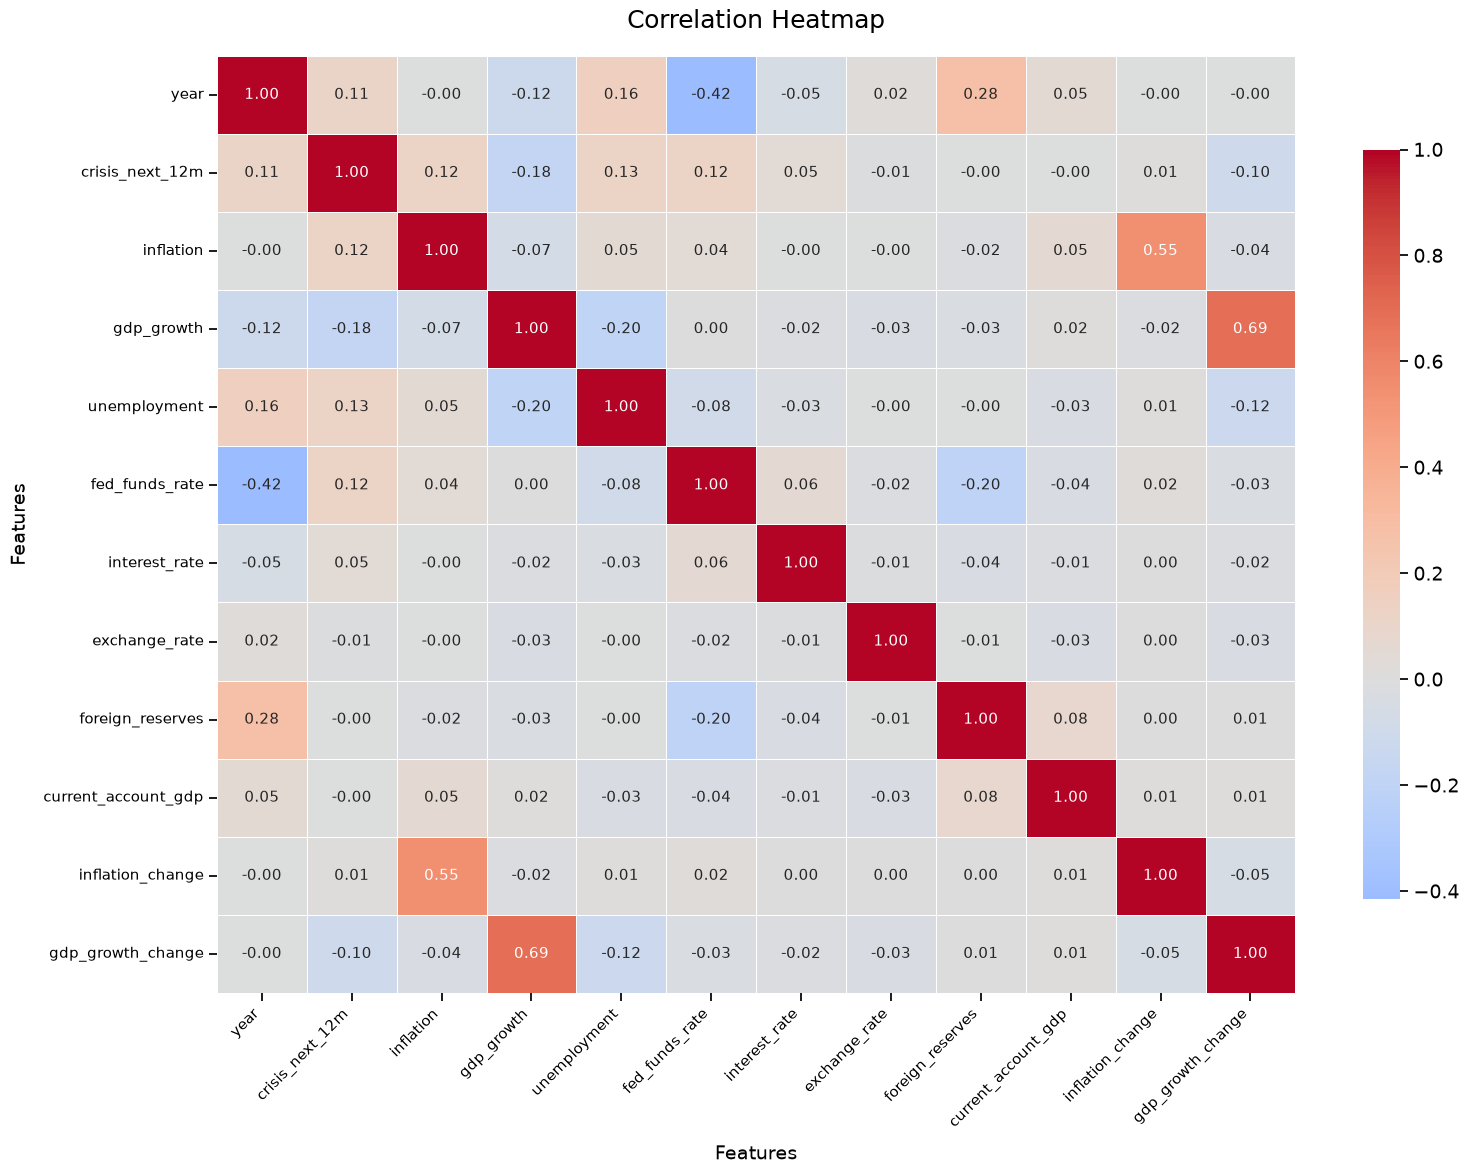

In [145]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    corrleation_after,
    annot=True,              # إظهار أرقام الـ Correlation داخل الخلايا
    fmt='.2f',               # عرض الرقم بمنزلتين عشريتين
    cmap='coolwarm',         # ألوان توضح القيم السالبة والموجبة
    center=0,                # جعل الصفر في منتصف مقياس الألوان
    linewidths=0.5,          # إضافة مسافات بين الخلايا
    linecolor='white',
    annot_kws={'size': 11},  # تكبير حجم الأرقام داخل الخلايا
    cbar_kws={'shrink': 0.8} # ضبط حجم شريط الألوان الجانبي
)

plt.title('Correlation Heatmap', fontsize=18, pad=20)
plt.xlabel('Features', fontsize=14, labelpad=10)
plt.ylabel('Features', fontsize=14, labelpad=10)

# تكبير أسماء الأعمدة والصفوف
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

<Axes: >

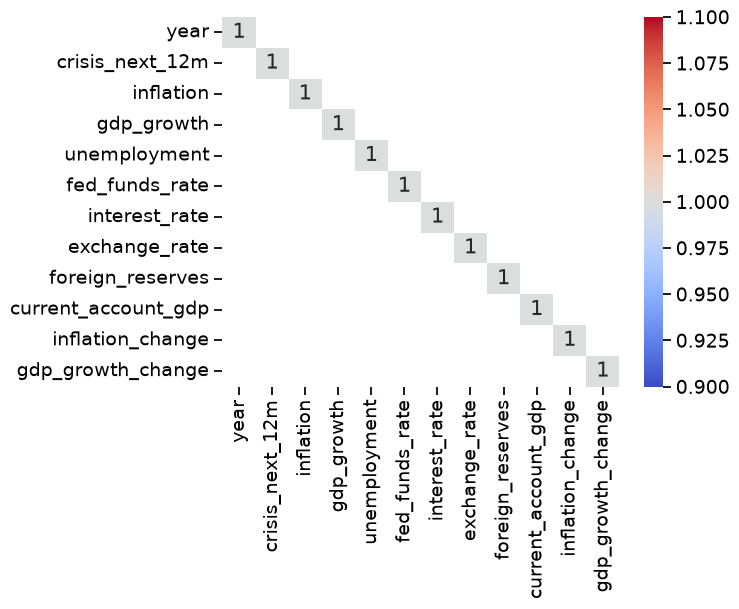

In [146]:
sns.heatmap(corrleation_after, annot=True,mask=corrleation_after<.90, cmap='coolwarm')
#كده الداتا تمام مفيش عمودين بيعلموا نفس الحاجه

crisis_next_12m
0    2923
1     939
Name: count, dtype: int64


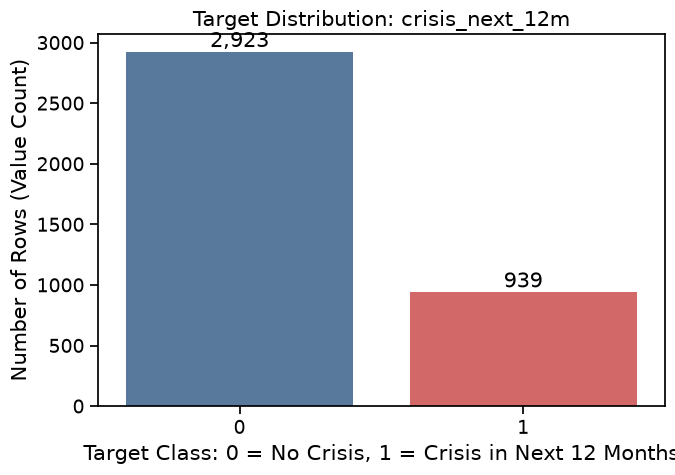

In [147]:
# value_counts() يحسب عدد الصفوف في كل Class.
# المحور X يوضح Class، والمحور Y يوضح عدد الصفوف في كل Class.
class_counts = df[target].value_counts().sort_index()
print(class_counts)

plt.figure(figsize=(7, 5))
ax = sns.barplot(x=class_counts.index.astype(str), y=class_counts.values,
                 hue=class_counts.index.astype(str), palette=['#4C78A8', '#E45756'], legend=False)
plt.title('Target Distribution: crisis_next_12m')
plt.xlabel('Target Class: 0 = No Crisis, 1 = Crisis in Next 12 Months')
plt.ylabel('Number of Rows (Value Count)')
for i, value in enumerate(class_counts.values):
    ax.text(i, value, f'{value:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


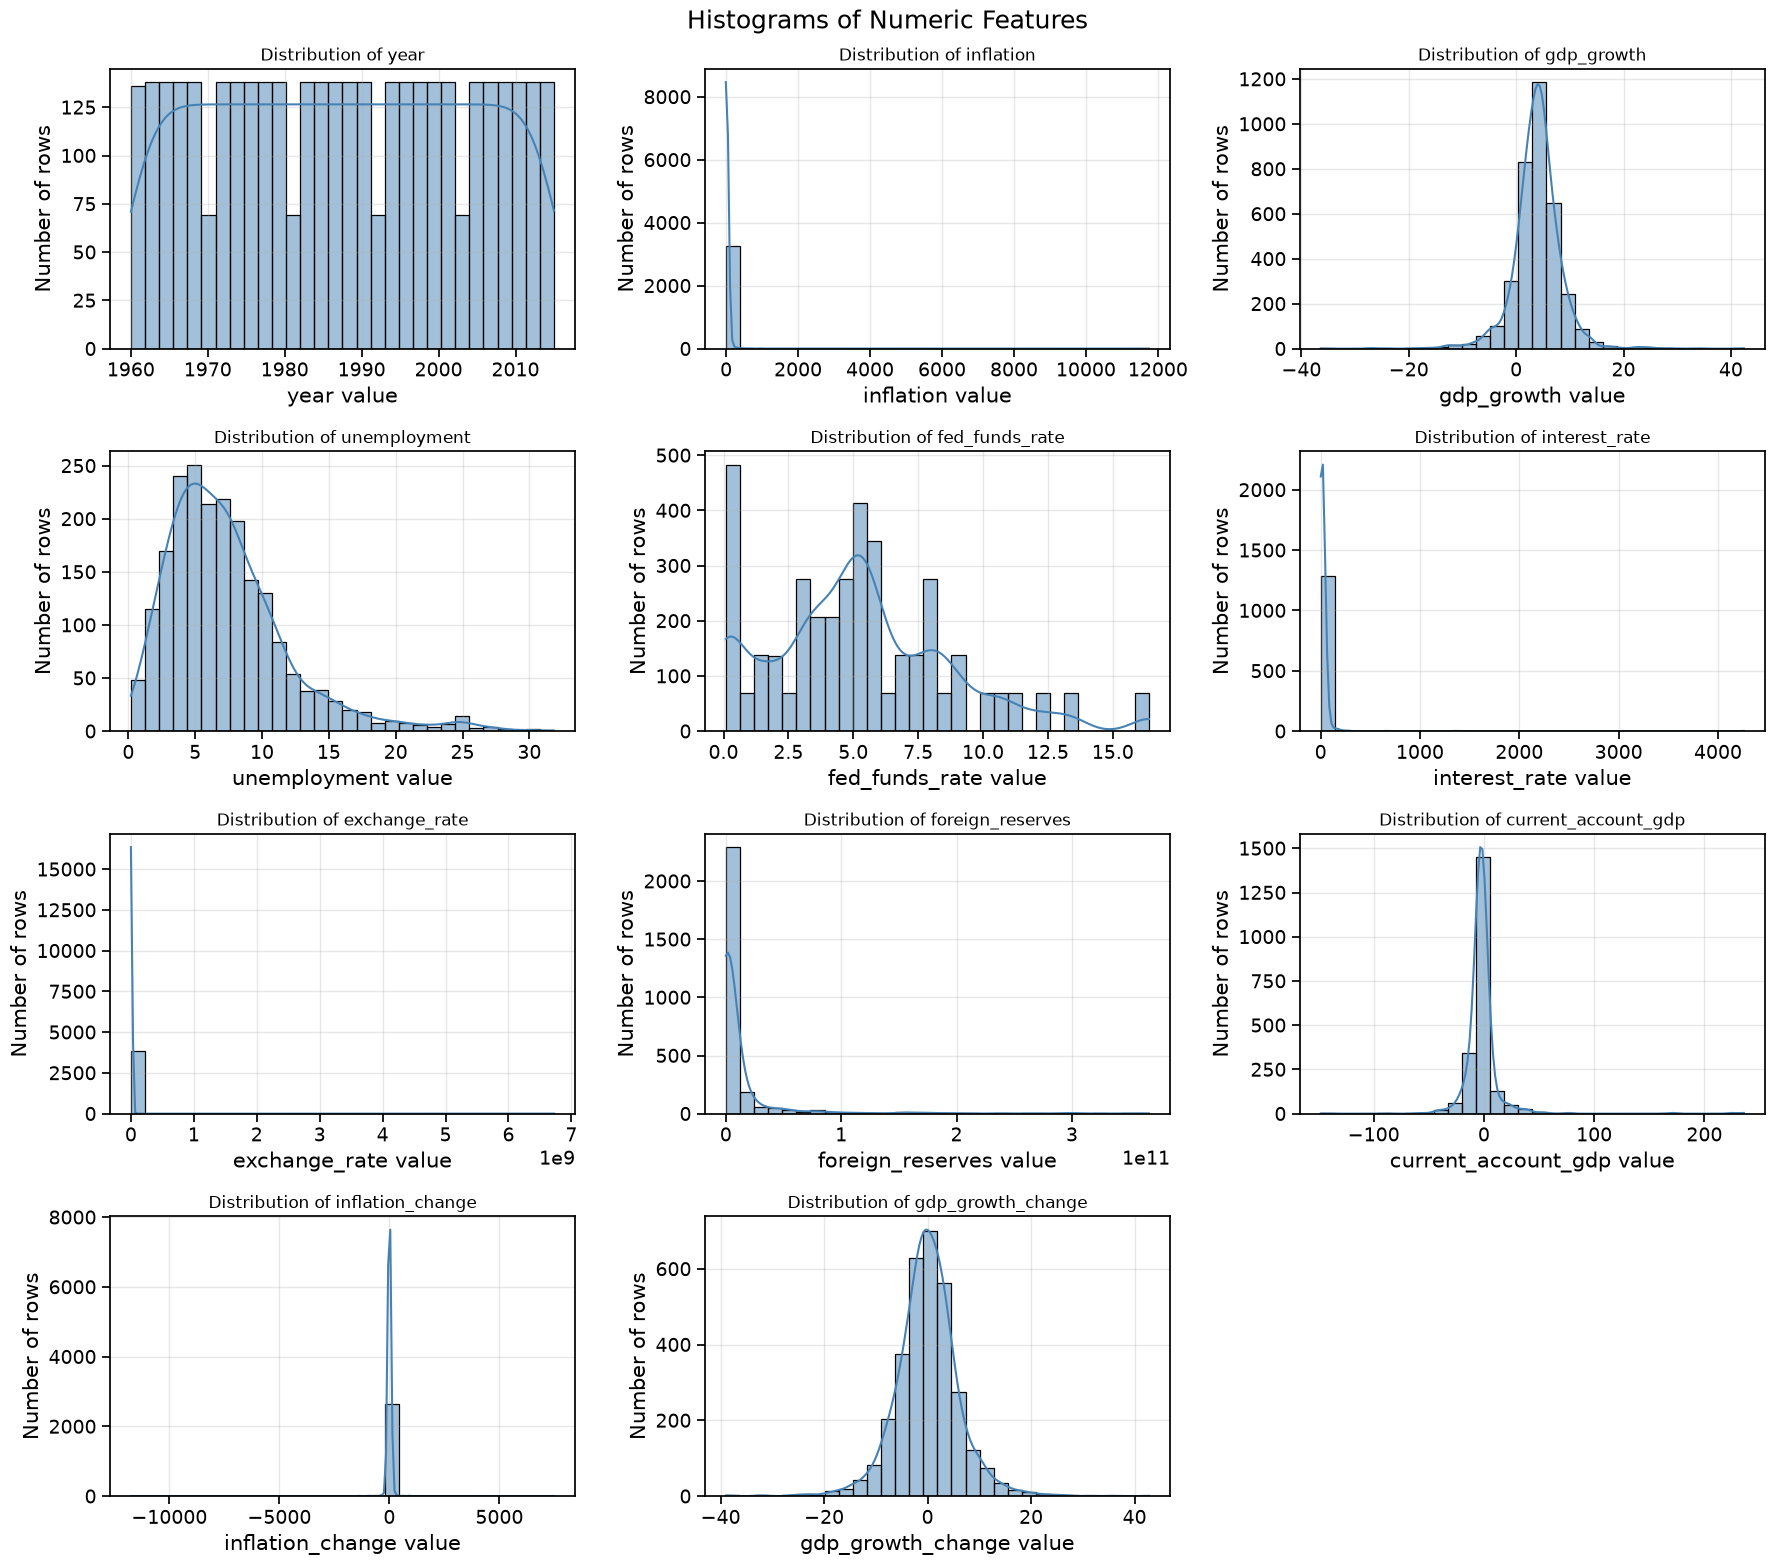

In [148]:
# عدد الأعمدة والصفوف في الشاشة
n_cols = 3
n_rows = int(np.ceil(len(numeric_features_after) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = np.array(axes).reshape(-1)

for ax, feature in zip(axes, numeric_features_after):
    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        kde=True,
        color='steelblue',
        ax=ax
    )
    ax.set_title(f'Distribution of {feature}', fontsize=12)
    ax.set_xlabel(f'{feature} value')
    ax.set_ylabel('Number of rows')
    ax.grid(alpha=0.3)

# إخفاء الخانات الزائدة
for ax in axes[len(numeric_features_after):]:
    ax.axis('off')

fig.suptitle('Histograms of Numeric Features', fontsize=18)
plt.tight_layout()
plt.show()


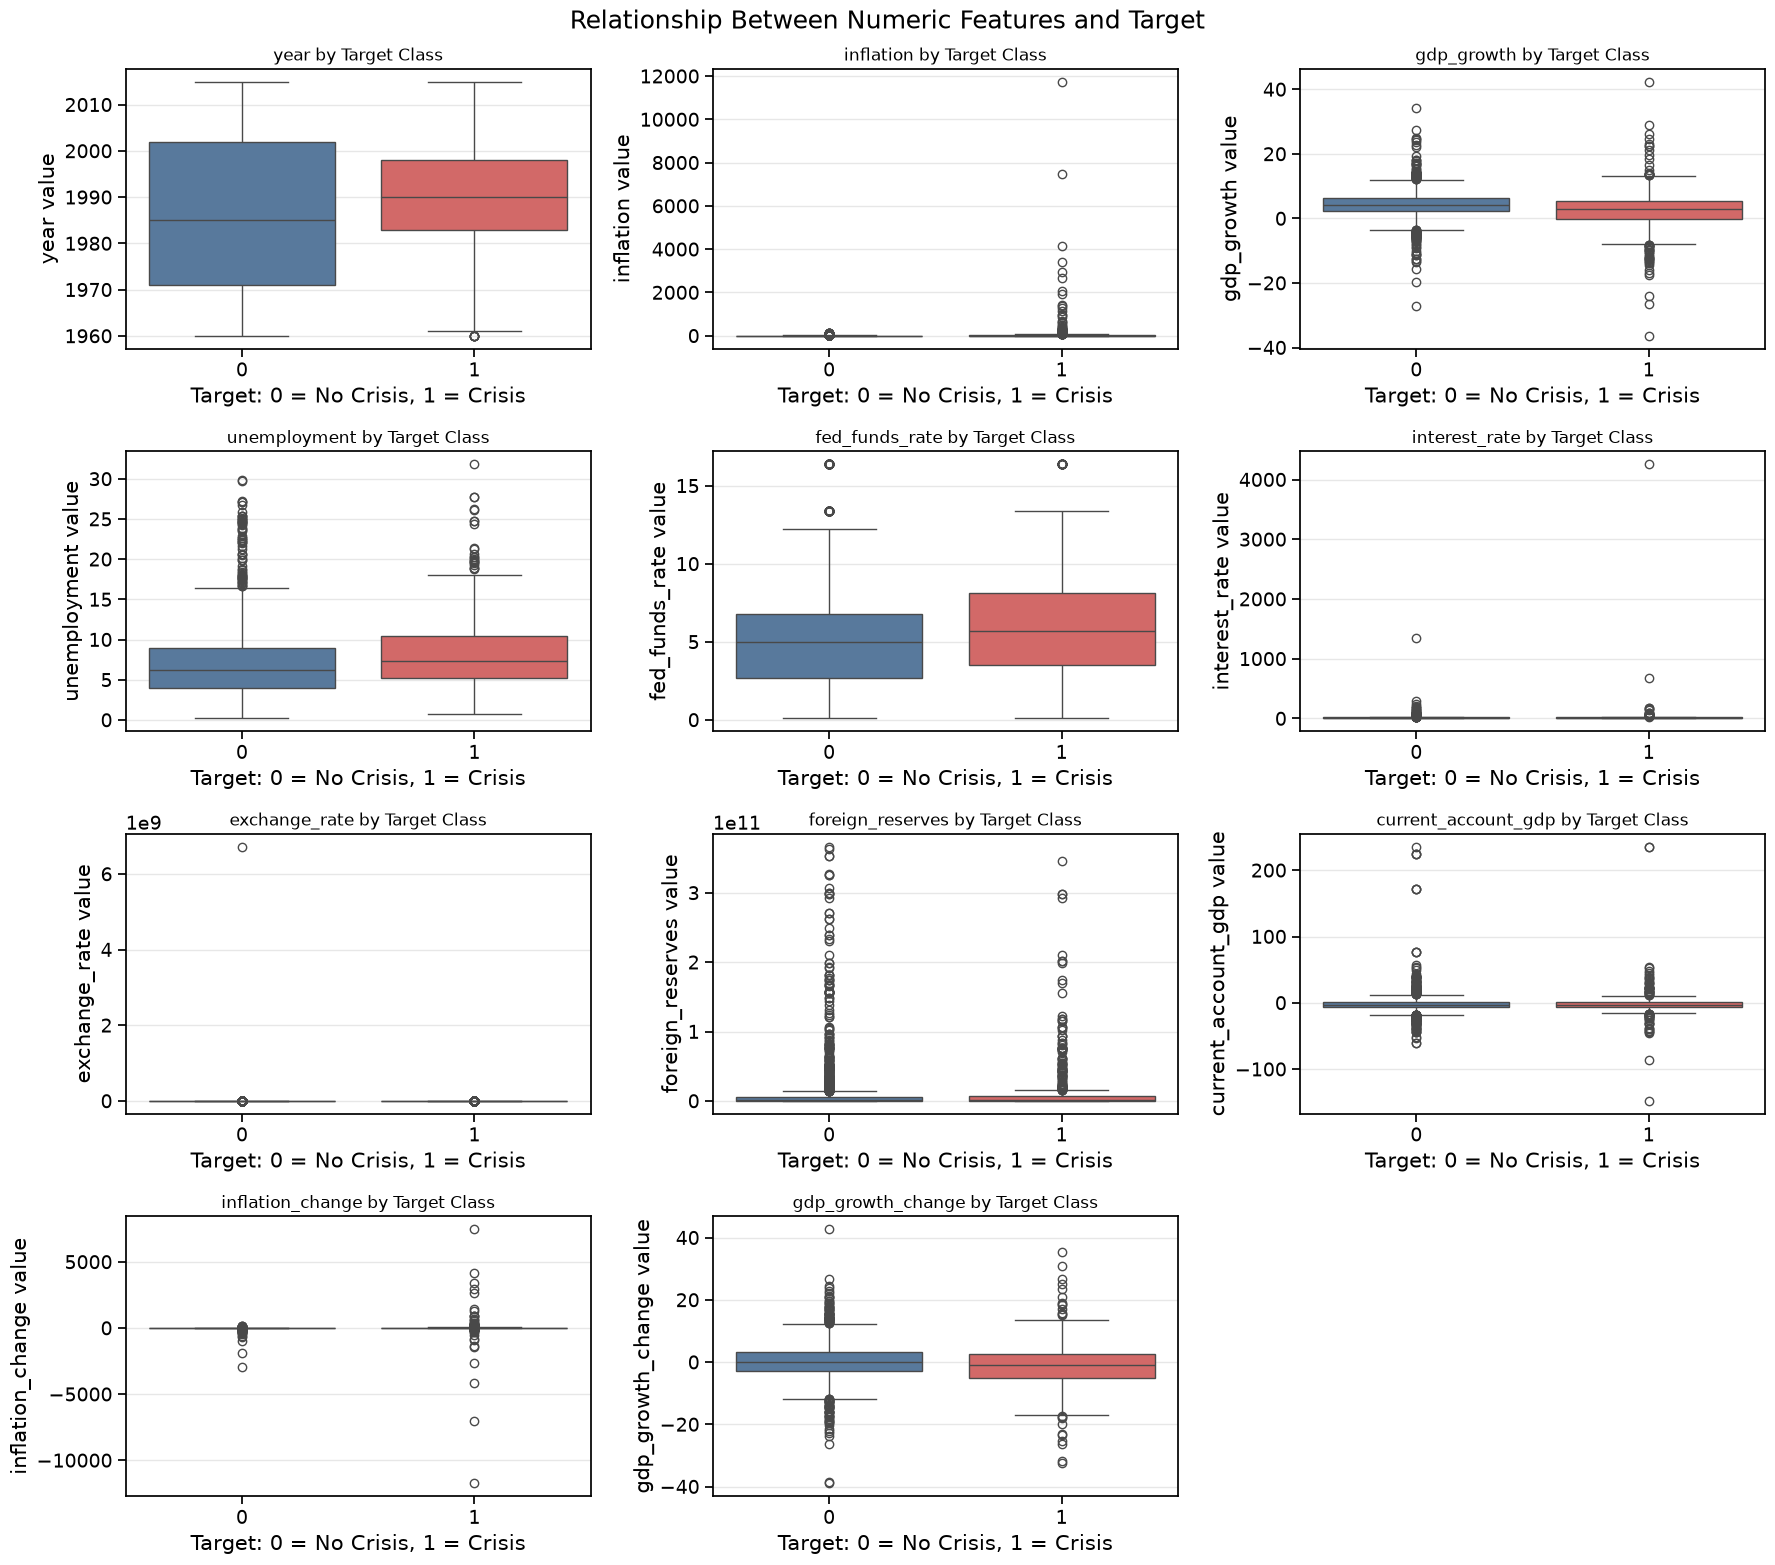

In [149]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_features_after) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, n_rows * 4)
)

# نحول axes إلى Array حتى يعمل الكود سواء كان لدينا رسم واحد أو عدة رسومات
axes = np.asarray(axes).reshape(-1)

for ax, feature in zip(axes, numeric_features_after):
    
    # نستخدم Boxplot لأن crisis_next_12m Target ثنائي:
    # Class 0 = No Crisis
    # Class 1 = Crisis
    # والهدف هو مقارنة توزيع كل Feature بين الفئتين.
    # Boxplot يوضح Median والتشتت والقيم المتطرفة والتداخل بين Class 0 وClass 1.
    sns.boxplot(
        data=df,
        x='crisis_next_12m',
        y=feature,
        hue='crisis_next_12m',
        palette={
            0: '#4C78A8',
            1: '#E45756'
        },
        legend=False,
        ax=ax
    )

    # المحور X هو Target Class
    # المحور Y هو قيم الـ Feature
    ax.set_title(f'{feature} by Target Class', fontsize=12)
    ax.set_xlabel('Target: 0 = No Crisis, 1 = Crisis')
    ax.set_ylabel(f'{feature} value')
    ax.grid(axis='y', alpha=0.3)

# إخفاء الخانات الزائدة إذا كان عدد الرسومات لا يملأ الشاشة بالكامل
for ax in axes[len(numeric_features_after):]:
    ax.axis('off')

fig.suptitle(
    'Relationship Between Numeric Features and Target',
    fontsize=18
)

plt.tight_layout()
plt.show()

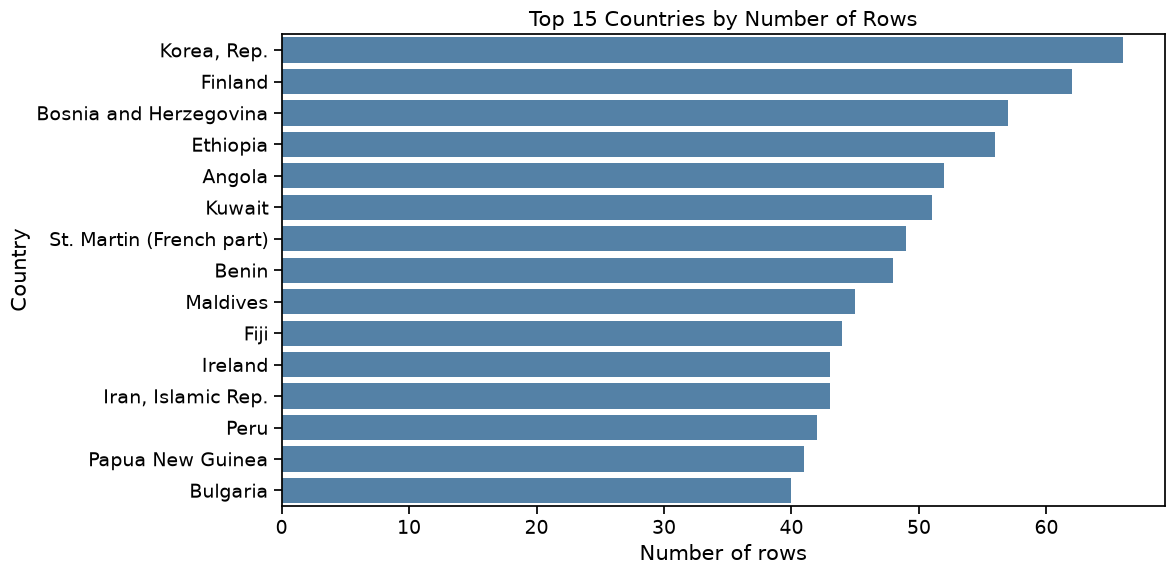

In [150]:
plt.figure(figsize=(12, 6))

country_counts = df['country'].value_counts().head(15)

sns.barplot(
    x=country_counts.values,
    y=country_counts.index,
    color='steelblue'
)

plt.title('Top 15 Countries by Number of Rows')
plt.xlabel('Number of rows')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


In [151]:
outlier_summary = []

for feature in numeric_features_after:
    values = df[feature].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # تحديد القيم المحتملة الشاذة في العمود الحالي
    outliers = values[
        (values < lower_bound) |
        (values > upper_bound)
    ]

    # الاحتفاظ بالثلاثة أعمدة المطلوبة فقط
    outlier_summary.append({
        'Feature': feature,
        'Potential Outliers': len(outliers),
        'Outlier Percentage': round(
            len(outliers) / len(values) * 100,
            2
        )
    })

# تحويل النتائج إلى DataFrame
outlier_summary = pd.DataFrame(outlier_summary)

# ترتيب الأعمدة حسب عدد الـ Outliers
outlier_summary = outlier_summary.sort_values(
    'Potential Outliers',
    ascending=False
)

outlier_summary


,Feature,Potential Outliers,Outlier Percentage
6,exchange_rate,681,17.82
7,foreign_reserves,423,15.37
9,inflation_change,418,15.60
1,inflation,313,9.52
8,current_account_gdp,249,11.84
2,gdp_growth,192,5.39
10,gdp_growth_change,140,4.40
5,interest_rate,113,8.67
3,unemployment,86,4.14
4,fed_funds_rate,69,1.79


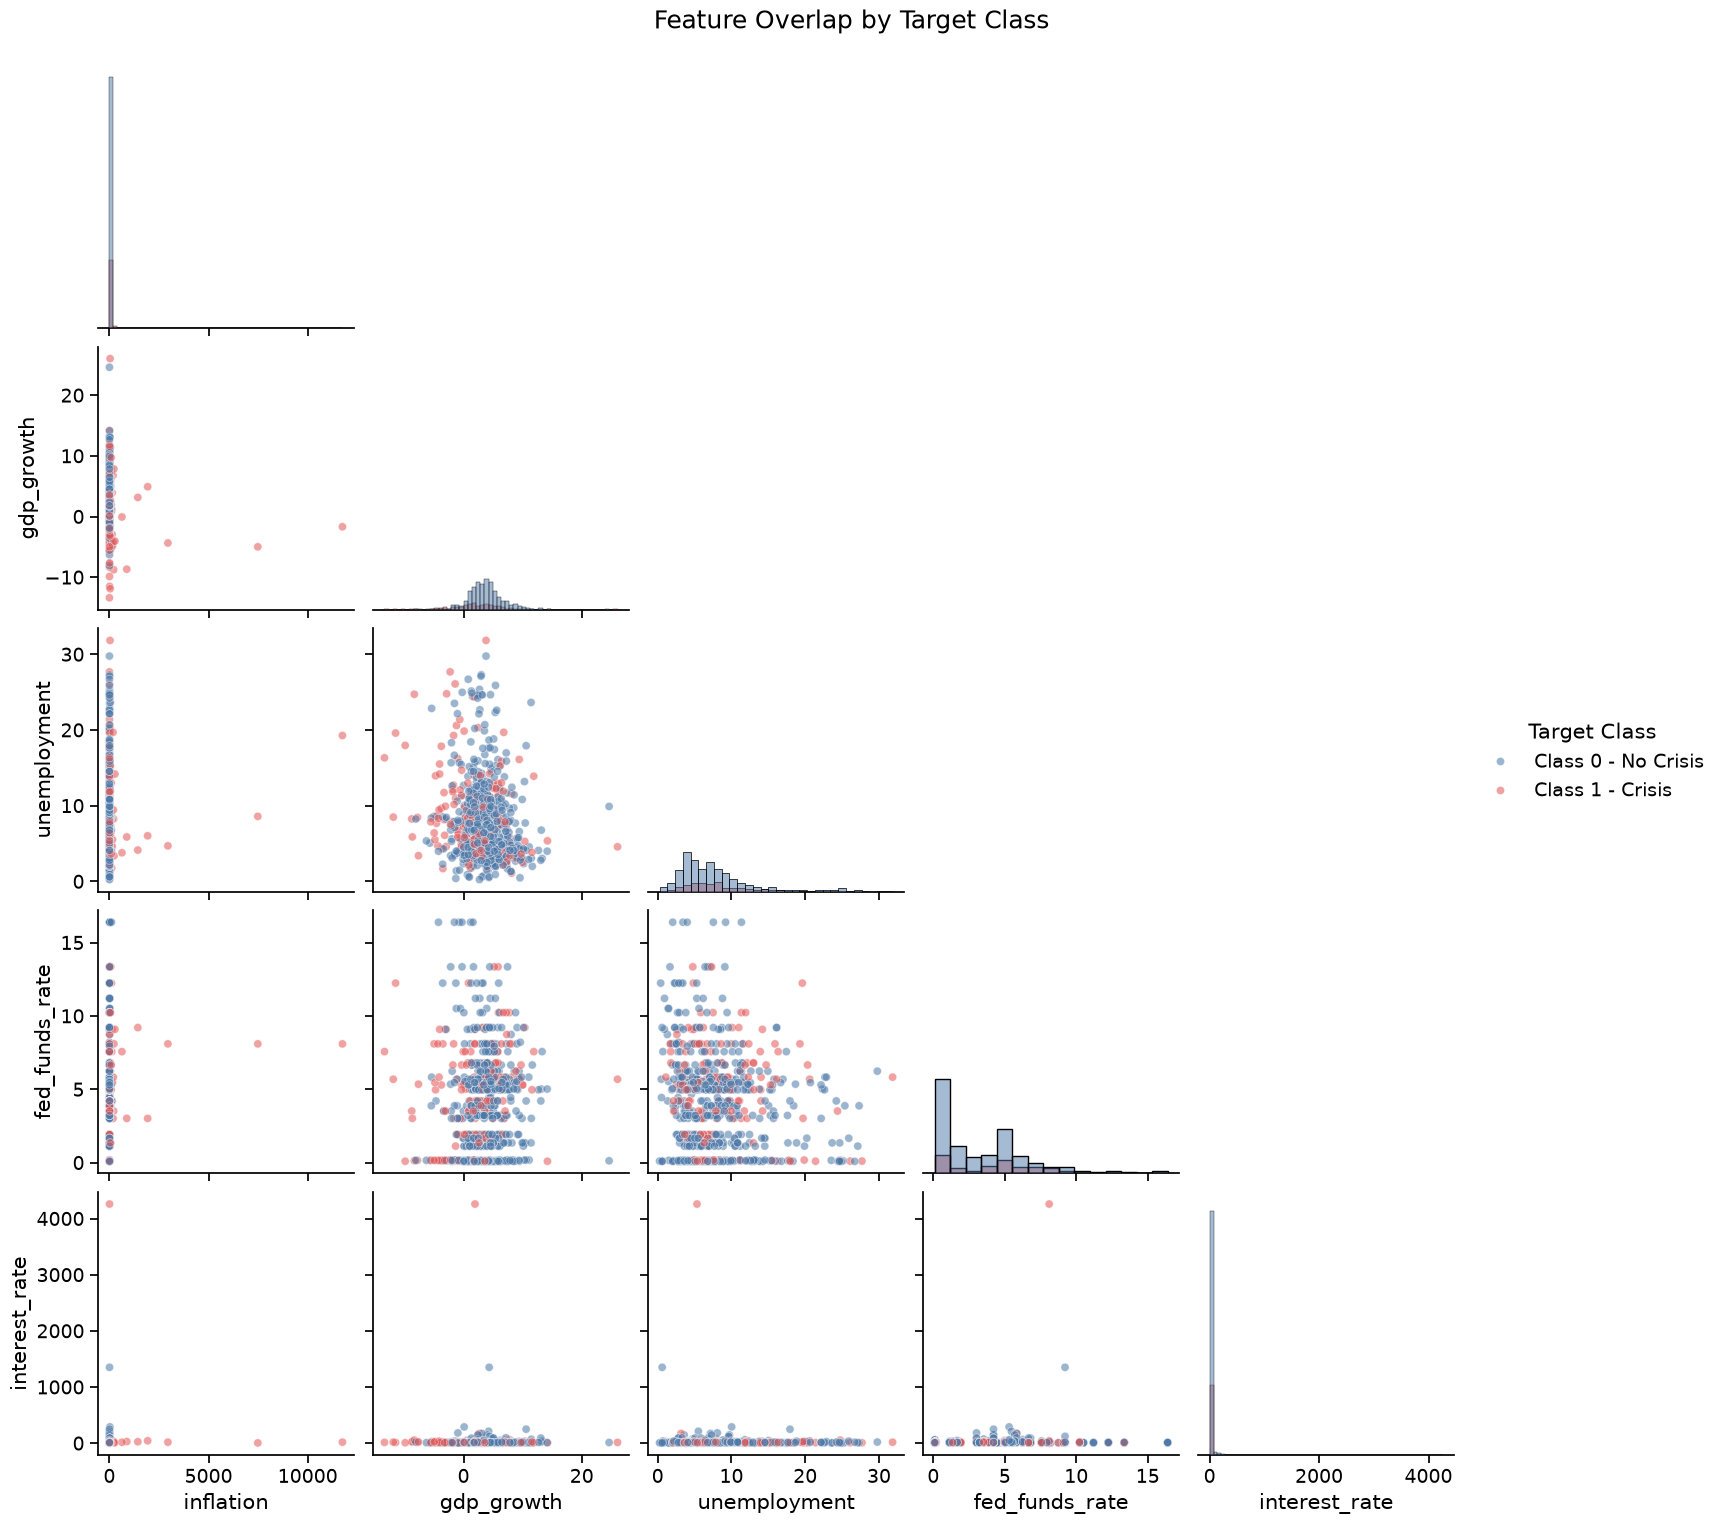

In [152]:
selected_features = [
    'inflation',
    'gdp_growth',
    'unemployment',
    'fed_funds_rate',
    'interest_rate'
]

selected_features = [
    col for col in selected_features
    if col in df.columns
]

plot_df = df[
    selected_features + ['crisis_next_12m']
].dropna()

plot_df['Target Class'] = plot_df['crisis_next_12m'].map({
    0: 'Class 0 - No Crisis',
    1: 'Class 1 - Crisis'
})

pair_plot = sns.pairplot(
    plot_df,
    vars=selected_features,
    hue='Target Class',
    diag_kind='hist',
    corner=True,
    height=3,
    plot_kws={
        'alpha': 0.55,
        's': 35
    },
    palette={
        'Class 0 - No Crisis': '#4C78A8',
        'Class 1 - Crisis': '#E45756'
    }
)

pair_plot.fig.suptitle(
    'Feature Overlap by Target Class',
    y=1.02,
    fontsize=18
)

plt.show()


In [153]:
#طبقا لي التلحيل احنا مش نحذف اي outliers لانها قيم logic تمام 
#ثانيا افضل مودلين نستخدمه لان بعض ال الاعمده مش normal destribuation skwed يعني 
#انسب مودلين ليهم هو random forest وي descion tree لانهم مش هيتاثر بشكل كبير بسبب المشكله ديه 
#ويقدروا يتعاملوا مع ال outliers كويس جدا 